link colab: https://colab.research.google.com/drive/1x8uDRspyHNC2XqQ8RqhJJPhSRjvPjbF0?usp=sharing

link deploy: https://mentalcheck.streamlit.app

link github: https://github.com/fauzanarif05/mentalcheck-depression-detection

# Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import pickle
import os
import json
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import SVC
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Import Dataset

In [2]:
file_path = '/content/drive/MyDrive/BENGKOD/PROYEK FAST TRACK/Bengkod-Depresi.csv'
df = pd.read_csv(file_path)
df

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33,Visakhapatnam,Student,5,0,8.97,2,0,5-6 hours,Healthy,B.Pharm,Yes,3,1.0,No,1.0
1,8,Female,24,Bangalore,Student,2,0,5.90,5,0,5-6 hours,Moderate,BSc,No,3,2.0,Yes,0.0
2,26,Male,31,Srinagar,Student,3,0,7.03,5,0,Less than 5 hours,Healthy,BA,No,9,1.0,Yes,0.0
3,30,Female,28,Varanasi,Student,3,0,5.59,2,0,7-8 hours,Moderate,BCA,Yes,4,5.0,Yes,1.0
4,32,Female,25,Jaipur,Student,4,0,8.13,3,0,5-6 hours,Moderate,M.Tech,Yes,1,1.0,No,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28003,103,Female,19,Kalyan,Student,5,0,5.64,5,0,Less than 5 hours,Moderate,Class 12,Yes,4,5.0,Yes,1.0
28004,106,Male,29,Srinagar,Student,3,0,8.58,3,0,More than 8 hours,Moderate,M.Tech,Yes,10,2.0,Yes,1.0
28005,120,Male,25,Nashik,Student,5,0,6.51,2,0,Less than 5 hours,Unhealthy,M.Ed,Yes,2,5.0,Yes,1.0
28006,132,Female,20,Ahmedabad,Student,5,0,7.25,3,0,5-6 hours,Healthy,Class 12,Yes,10,3.0,No,1.0


# Eksplorasi Data Analisis (EDA)

In [3]:
# Memeriksa informasi dataset, tipe data, dan nilai yang kosong
print("--- Informasi Dataset ---")
print(df.info())

print("\n--- Jumlah Nilai Kosong ---")
print(df.isnull().sum())

print("\n--- Jumlah Nilai Duplikat ---")
duplicate_count = df.duplicated().sum()
print(f"Jumlah data duplikat: {duplicate_count}")

print("\n--- Statistik Deskriptif ---")
display(df.describe())

--- Informasi Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28008 entries, 0 to 28007
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     28008 non-null  int64  
 1   Gender                                 28008 non-null  object 
 2   Age                                    28008 non-null  int64  
 3   City                                   28008 non-null  object 
 4   Profession                             28008 non-null  object 
 5   Academic Pressure                      28008 non-null  int64  
 6   Work Pressure                          28008 non-null  int64  
 7   CGPA                                   28008 non-null  float64
 8   Study Satisfaction                     28008 non-null  int64  
 9   Job Satisfaction                       28008 non-null  int64  
 10  Sleep Duration                         28008

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
count,28008.000000,28008.000000,28008.000000,28008.000000,28008.000000,28008.000000,28008.000000,28008.000000,27963.000000,27966.000000
mean,70613.609933,25.824264,3.141245,0.000428,7.655372,2.944337,0.000678,7.154456,3.139077,0.585354
std,40792.430225,4.903456,1.380940,0.043908,1.470506,1.361318,0.044310,3.708348,1.437839,0.492670
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,35075.500000,21.000000,2.000000,0.000000,6.287500,2.000000,0.000000,4.000000,2.000000,0.000000
50%,70855.000000,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,3.000000,1.000000
75%,106075.750000,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,4.000000,1.000000
max,141248.000000,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,5.000000,1.000000


In [4]:
# definisikan kolom numerik dan kategorikal
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

In [5]:
print("--- Nilai Unik di Tiap Kolom Kategorikal ---\n")
for col in cat_cols:
    unique_values = df[col].unique()
    print(f"Kolom: {col}")
    print(f"Jumlah unik: {len(unique_values)}")
    print(f"Nilai: {unique_values}\n")

--- Nilai Unik di Tiap Kolom Kategorikal ---

Kolom: Gender
Jumlah unik: 2
Nilai: ['Male' 'Female']

Kolom: City
Jumlah unik: 52
Nilai: ['Visakhapatnam' 'Bangalore' 'Srinagar' 'Varanasi' 'Jaipur' 'Pune' 'Thane'
 'Chennai' 'Nagpur' 'Nashik' 'Vadodara' 'Kalyan' 'Rajkot' 'Ahmedabad'
 'Kolkata' 'Mumbai' 'Lucknow' 'Indore' 'Surat' 'Ludhiana' 'Bhopal'
 'Meerut' 'Agra' 'Ghaziabad' 'Hyderabad' 'Vasai-Virar' 'Kanpur' 'Patna'
 'Faridabad' 'Delhi' 'Saanvi' 'M.Tech' 'Bhavna' 'Less Delhi' 'City' '3'
 'Less than 5 Kalyan' 'Mira' 'Harsha' 'Vaanya' 'Gaurav' 'Harsh' 'Reyansh'
 'Kibara' 'Rashi' 'ME' 'M.Com' 'Nalyan' 'Mihir' 'Nalini' 'Nandini'
 'Khaziabad']

Kolom: Profession
Jumlah unik: 14
Nilai: ['Student' 'Civil Engineer' 'Architect' 'UX/UI Designer'
 'Digital Marketer' 'Content Writer' 'Educational Consultant' 'Teacher'
 'Manager' 'Chef' 'Doctor' 'Lawyer' 'Entrepreneur' 'Pharmacist']

Kolom: Sleep Duration
Jumlah unik: 5
Nilai: ['5-6 hours' 'Less than 5 hours' '7-8 hours' 'More than 8 hours' 'Others

In [6]:
# Menampilkan nilai unik dan jumlahnya untuk setiap kolom numerik
print("--- Nilai Unik & Jumlahnya pada Kolom Numerik ---\n")
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    print(f"Kolom: {col}")
    print(f"Jumlah Nilai Unik: {df[col].nunique()}")
    print("Distribusi Nilai:")
    print(df[col].value_counts().sort_index())
    print("-" * 30 + "\n")

--- Nilai Unik & Jumlahnya pada Kolom Numerik ---

Kolom: id
Jumlah Nilai Unik: 27962
Distribusi Nilai:
id
2         2
8         2
26        2
30        2
32        2
         ..
141212    1
141221    1
141230    1
141239    1
141248    1
Name: count, Length: 27962, dtype: int64
------------------------------

Kolom: Age
Jumlah Nilai Unik: 34
Distribusi Nilai:
Age
18    1590
19    1565
20    2240
21    1732
22    1163
23    1654
24    2270
25    1792
26    1157
27    1472
28    2142
29    1958
30    1151
31    1437
32    1267
33    1899
34    1470
35      10
36       7
37       2
38       8
39       3
41       1
42       4
43       2
44       1
46       2
48       3
49       1
51       1
54       1
56       1
58       1
59       1
Name: count, dtype: int64
------------------------------

Kolom: Academic Pressure
Jumlah Nilai Unik: 6
Distribusi Nilai:
Academic Pressure
0       9
1    4810
2    4204
3    7496
4    5171
5    6318
Name: count, dtype: int64
------------------------------

K

--- Distribusi Kolom Target (Depression) ---
Depression
1.0    16370
0.0    11596
Name: count, dtype: int64


/tmp/ipykernel_39771/3742059552.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Depression', data=df, palette='viridis')


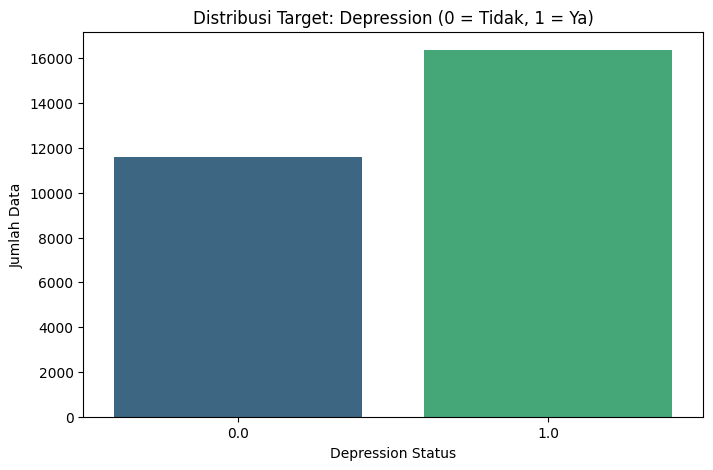

In [7]:
# Menghitung distribusi nilai pada kolom target 'Depression'
distribusi_target = df['Depression'].value_counts()

print("--- Distribusi Kolom Target (Depression) ---")
print(distribusi_target)

# Visualisasi distribusi
plt.figure(figsize=(8, 5))
sns.countplot(x='Depression', data=df, palette='viridis')
plt.title('Distribusi Target: Depression (0 = Tidak, 1 = Ya)')
plt.xlabel('Depression Status')
plt.ylabel('Jumlah Data')
plt.show()

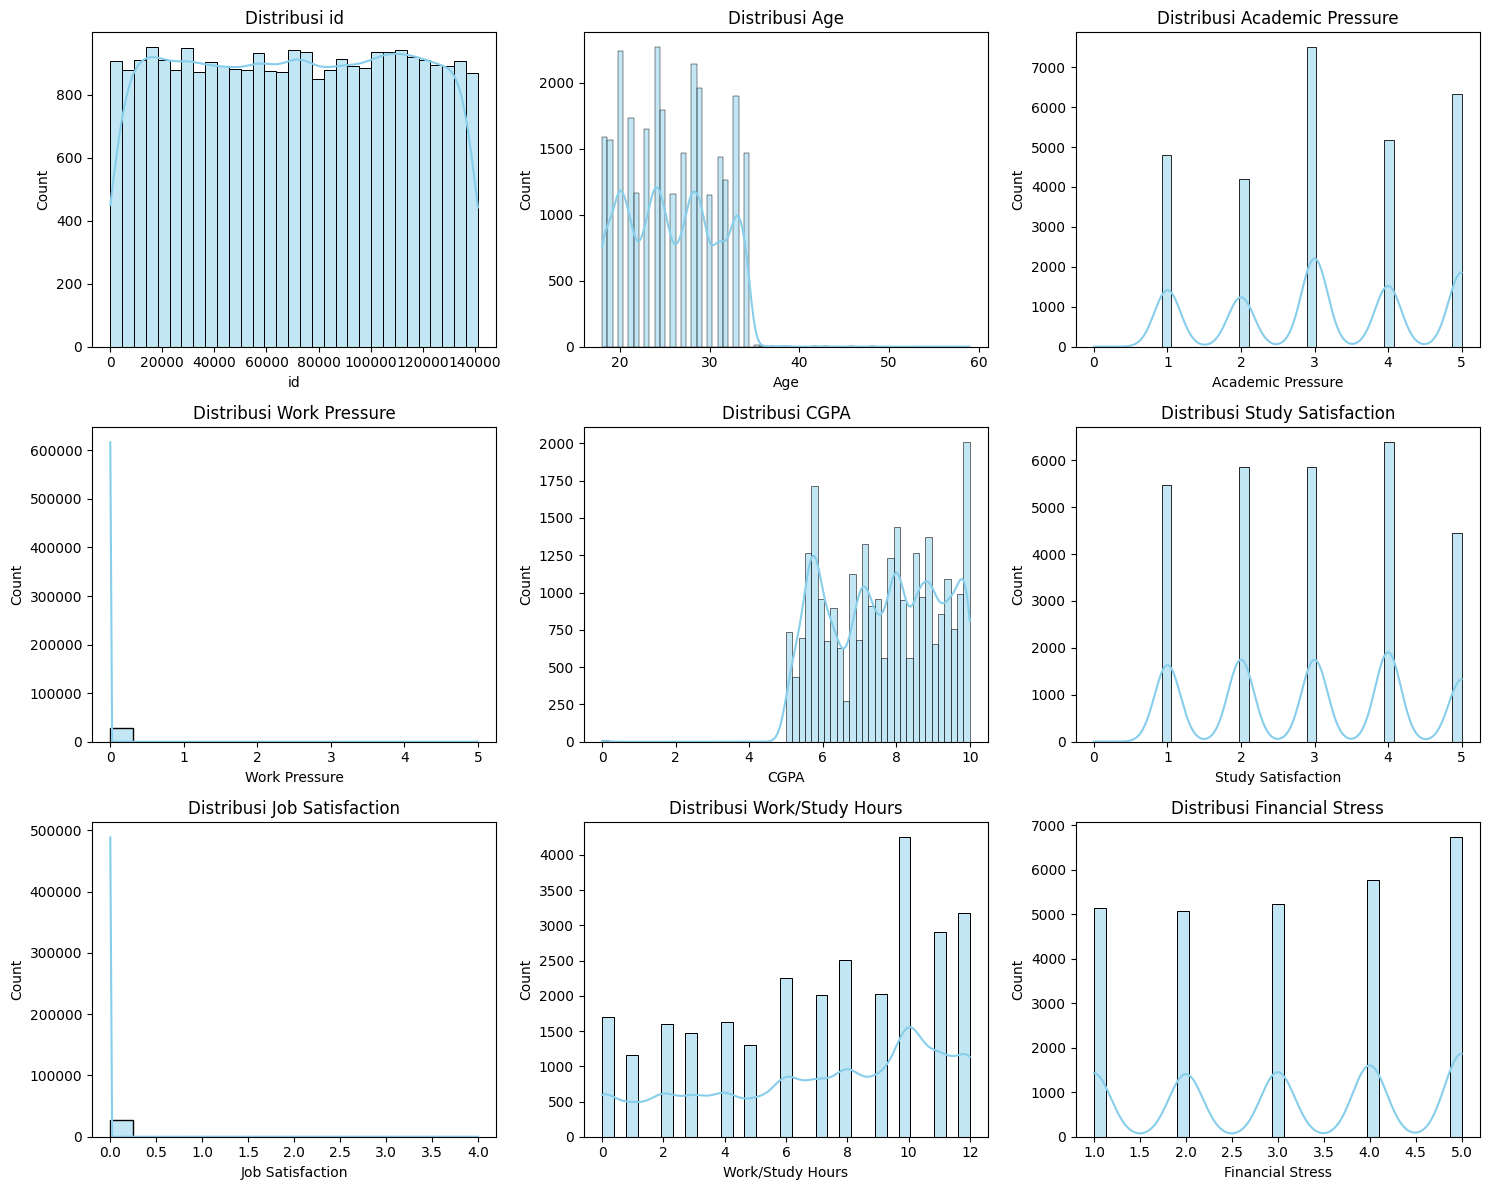

In [8]:
# Identify numerical columns excluding the target 'Depression'
num_cols = [col for col in num_cols if col != 'Depression']

n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

plt.figure(figsize=(15, n_rows * 4))
for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribusi {col}')

plt.tight_layout()
plt.show()

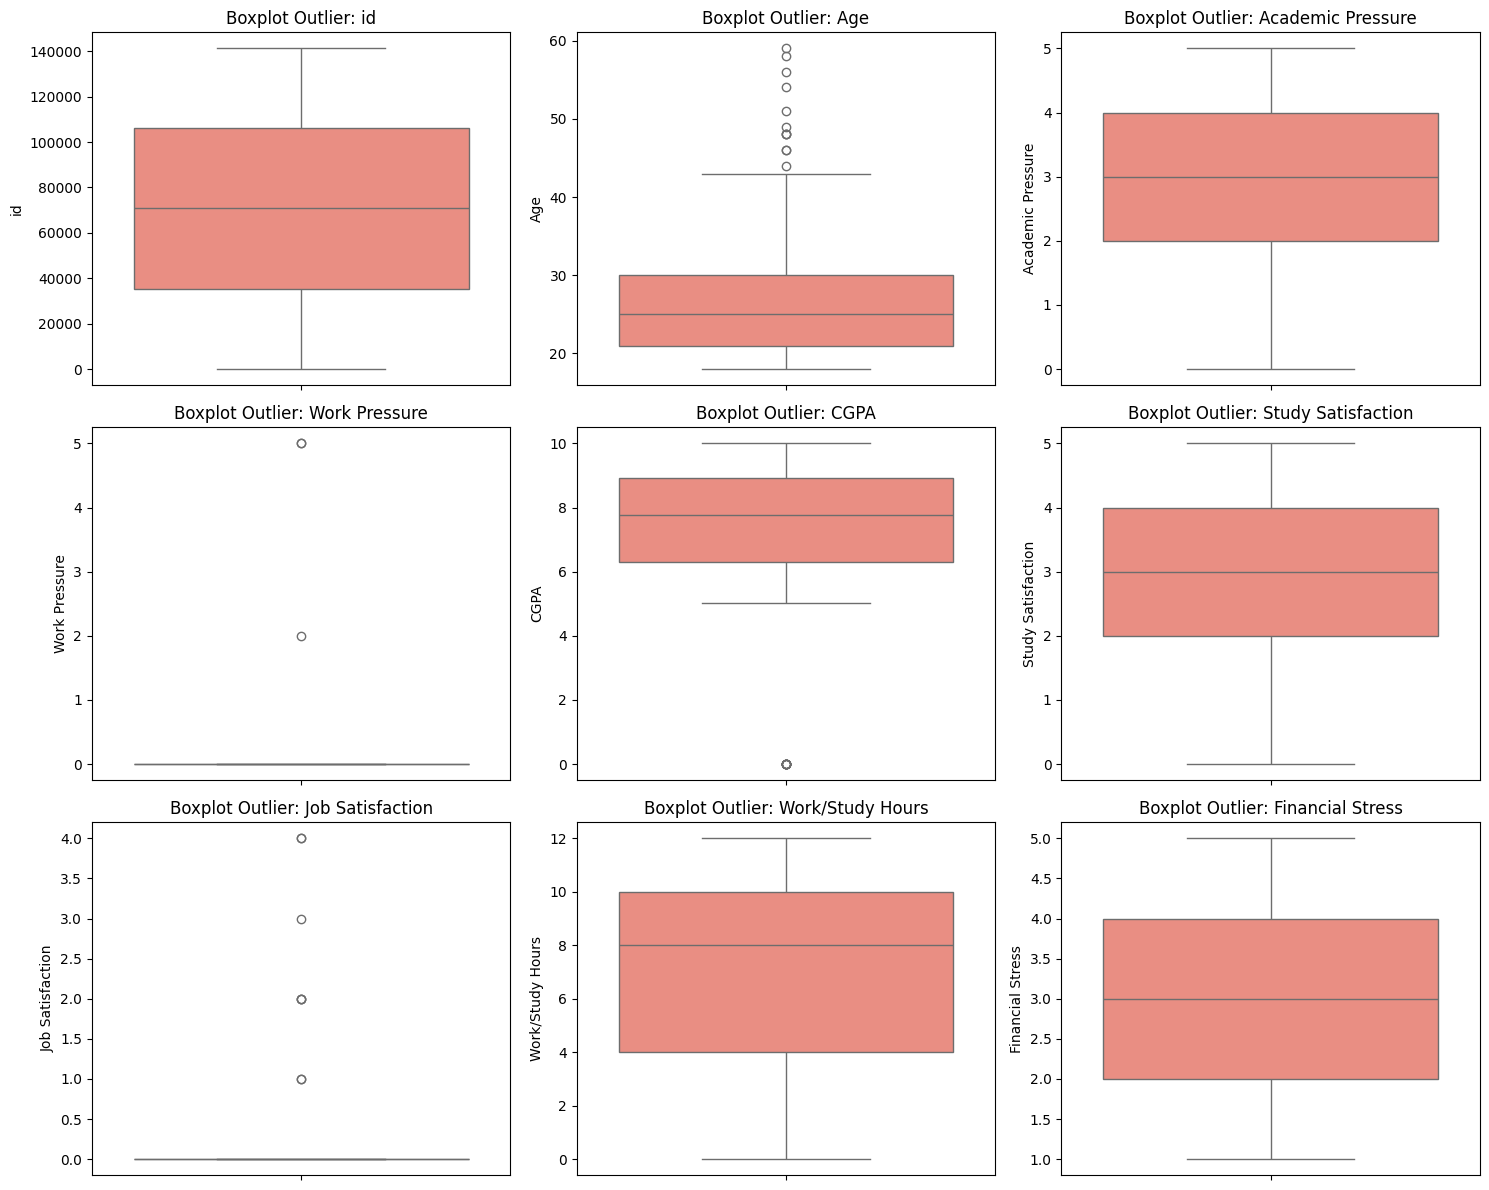

In [9]:
# Hitung jumlah baris yang dibutuhkan untuk grid (3 kolom per baris)
n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

plt.figure(figsize=(15, n_rows * 4))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=df[col], color='salmon')
    plt.title(f'Boxplot Outlier: {col}')

plt.tight_layout()
plt.show()

/tmp/ipykernel_39771/3081239690.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='magma')
/tmp/ipykernel_39771/3081239690.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='magma')
/tmp/ipykernel_39771/3081239690.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='magma')
/tmp/ipykernel_39771/3081239690.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legen

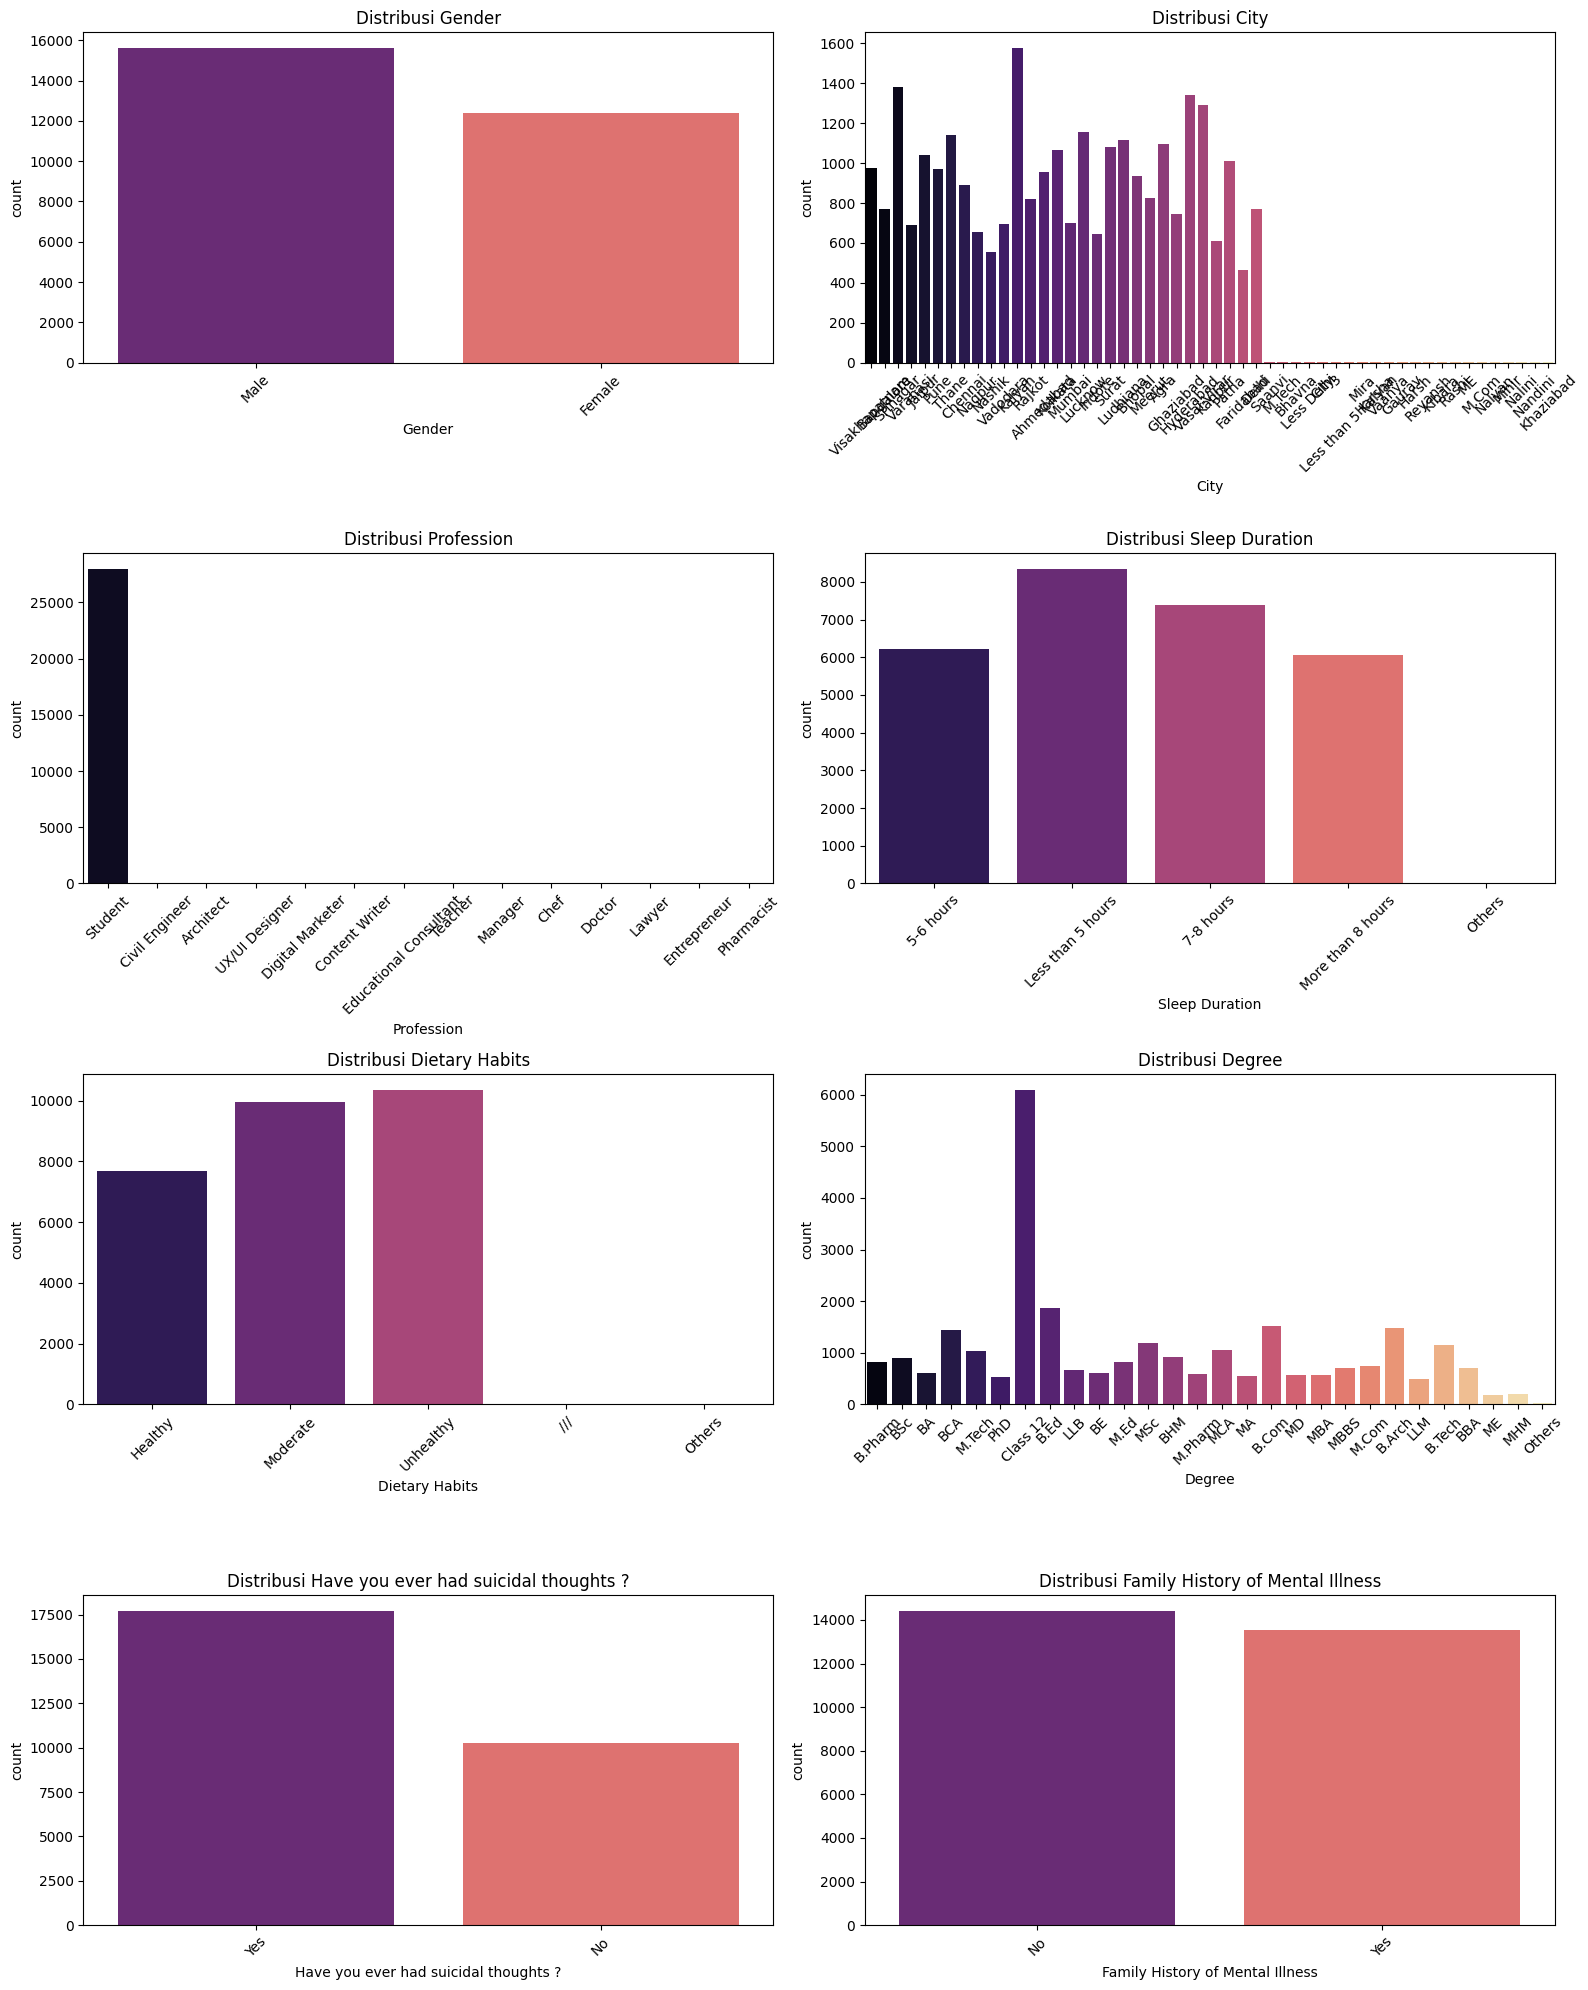

In [10]:
# Hitung grid
n_cols = 2
n_rows = math.ceil(len(cat_cols) / n_cols)

plt.figure(figsize=(16, n_rows * 5))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.countplot(x=col, data=df, palette='magma')
    plt.title(f'Distribusi {col}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [11]:
df['Profession'].value_counts()

,count
Profession,
Student,27977
Architect,8
Teacher,6
Digital Marketer,3
Chef,2
Content Writer,2
Pharmacist,2
Doctor,2
UX/UI Designer,1


In [12]:
df['Sleep Duration'].value_counts()

,count
Sleep Duration,
Less than 5 hours,8343
7-8 hours,7374
5-6 hours,6213
More than 8 hours,6060
Others,18


In [13]:
df['Degree'].value_counts()

,count
Degree,
Class 12,6097
B.Ed,1873
B.Com,1512
B.Arch,1486
BCA,1438
MSc,1195
B.Tech,1156
MCA,1047
M.Tech,1028


In [14]:
df['Dietary Habits'].value_counts()

,count
Dietary Habits,
Unhealthy,10354
Moderate,9959
Healthy,7682
Others,12
///,1


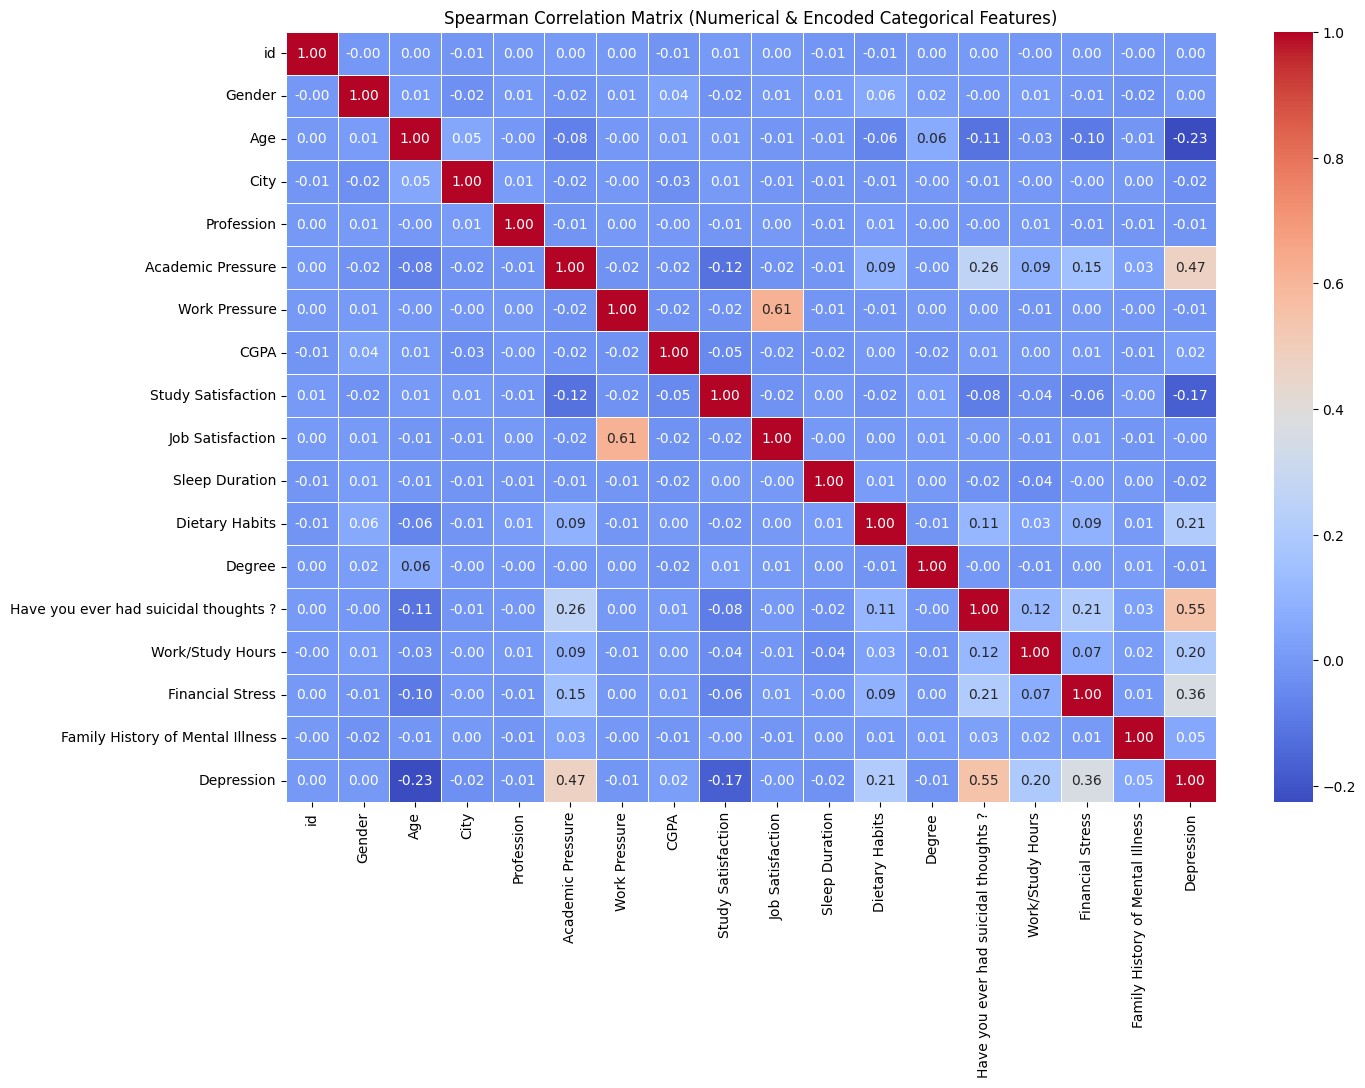

In [15]:
# 1. Buat variabel baru agar tidak mengganggu df atau df_clean
df_corr = df.copy()

# 2. Encode fitur kategorikal pada variabel baru
le_corr = LabelEncoder()
for col in df_corr.select_dtypes(include=['object']).columns:
    df_corr[col] = le_corr.fit_transform(df_corr[col].astype(str))

# 3. Hitung matrix korelasi Pearson
correlation_matrix = df_corr.corr(method='spearman')

# 4. Visualisasi Heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Spearman Correlation Matrix (Numerical & Encoded Categorical Features)')
plt.show()

# Direct Modeling

## Pemilihan 6 Algoritma Klasifikasi linear dan non-linear

### **3 Algoritma Linear (Untuk menguji apakah data cukup dipisah dengan garis lurus)**
Karena nantinya saya akan melakukan Scaling (StandardScaler), algoritma di bawah ini akan bekerja dengan performa maksimalnya.

1. Logistic Regression (LogReg)

Alasan: Ini adalah "Bapak" dari klasifikasi biner dan standar mutlak di dunia medis/psikologi. Sangat cepat dilatih.

Kelebihan Utama: Explainability (Bisa dijelaskan). LogReg akan memberikan bobot (koefisien) untuk setiap fitur. Kita bisa tahu persis, misalnya, "Berapa kali lipat risiko depresi jika waktu tidur kurang dari 5 jam dibandingkan orang normal?".

2. Support Vector Machine - Linear Kernel (LinearSVC)

Alasan: SVM mencari "jalan tol" (margin) terlebar yang memisahkan kelas 0 dan 1. Menggunakan Linear Kernel berarti kita memaksa SVM menarik garis lurus.

Kelebihan Utama: Sangat tangguh terhadap noise dan fitur yang mungkin kurang relevan.

3. Ridge Classifier

Alasan: Ini adalah model regresi linear yang diberi penalti (regularization L2) lalu diubah menjadi classifier.

Kelebihan Utama: Sangat hebat jika ternyata fitur-fitur pada dataset memiliki korelasi satu sama lain (misalnya, Academic Pressure dan Study Satisfaction beririsan maknanya). Ridge mencegah model bergantung hanya pada satu fitur dan membuat model lebih stabil.


### **3 Algoritma Non-Linear (Untuk menangkap pola kompleks dan interaksi tersembunyi)**
Algoritma ini tidak peduli dengan garis lurus. Mereka bisa membuat batas keputusan yang melengkung, memutar, atau berbentuk kotak-kotak.

4. Random Forest (RF)

Alasan: Algoritma berbasis pohon (tree-based) adalah raja untuk data tabular. Ia bekerja dengan membuat ratusan "Pohon Keputusan" lalu mengambil voting terbanyak.

Kelebihan Utama: Sangat kebal terhadap outlier (seperti usia 60 tahun tadi). Selain itu, RF memiliki fitur feature_importances_ yang sangat akurat untuk meranking kolom mana yang paling menyebabkan depresi.

5. XGBoost (Extreme Gradient Boosting)

Alasan: Algoritma paling populer dan sering menang di kompetisi Kaggle. Berbeda dengan RF yang membuat pohon secara acak, XGBoost membangun pohon secara berurutan; pohon baru fokus memperbaiki kesalahan tebakan pohon sebelumnya.

Kelebihan Utama: Akurasinya biasanya yang paling tinggi. XGBoost sangat mahir menemukan interaksi non-linear yang rumit (misalnya: Orang dengan CGPA tinggi + Jam Tidur rendah = Risiko Depresi melonjak tinggi).

6. K-Nearest Neighbors (KNN)

Alasan: KNN sangat intuitif. Ia menebak status seseorang dengan melihat status "tetangga terdekatnya". Algoritma ini murni mengandalkan jarak geometris.

Kelebihan Utama: KNN akan bekerja sangat baik saat datanya sudah di standarisasi. Algoritma ini hebat untuk membuktikan apakah orang dengan profil mirip (usia sama, jam tidur sama, tingkat stres sama) cenderung berkumpul dalam "klaster" depresi yang sama di ruang multi-dimensi.

In [16]:
# 1. Persiapan Data (Tanpa hapus NaN/Duplikat)
df_direct = df.copy().dropna()

# 2. Encoding Fitur (Ordinal) dan Label (LabelEncoder)
cat_features = df_direct.select_dtypes(include=['object']).columns
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df_direct[cat_features] = encoder.fit_transform(df_direct[cat_features].astype(str))

# Encode Target jika bertipe object atau float yang mengandung NaN (tetap dipertahankan)
le = LabelEncoder()
# Menggunakan fillna sementara hanya untuk proses fitting label agar tidak error,
# namun data asli tetap dipertahankan sesuai instruksi
y_temp = df_direct['Depression'].fillna(-1).astype(int)
df_direct['Depression'] = le.fit_transform(y_temp)

# 3. Split Data
X_direct = df_direct.drop('Depression', axis=1)
y_direct = df_direct['Depression']

X_train_direct, X_test_direct, y_train_direct, y_test_direct = train_test_split(
    X_direct, y_direct, test_size=0.2, random_state=42
)

# 4. Inisialisasi 6 Model (Sesuai bagian preprocessing)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "Ridge Classifier": RidgeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5)
}

print(f"6 Model telah siap untuk dilatih dengan fitur yang di-encode secara ordinal.")
print(f"Ukuran dataset: {df_direct.shape}")

6 Model telah siap untuk dilatih dengan fitur yang di-encode secara ordinal.
Ukuran dataset: (27963, 18)


In [17]:
# Dictionary untuk menyimpan hasil akurasi
results = {}

print("--- Memulai Proses Pelatihan dan Evaluasi (Direct Modeling) ---\n")

for name, model in models.items():
    # Melatih model
    model.fit(X_train_direct, y_train_direct)

    # Melakukan prediksi
    y_pred = model.predict(X_test_direct)

    # Menghitung akurasi
    acc = accuracy_score(y_test_direct, y_pred)
    results[name] = acc

    print(f"=== {name} ===")
    print(f"Accuracy: {acc:.4f}")
    print("Classification Report:")
    print(classification_report(y_test_direct, y_pred))
    print("-" * 30 + "\n")

print("--- Ringkasan Performa Model (Akurasi) ---")
# Mengurutkan hasil dari yang tertinggi
sorted_results = dict(sorted(results.items(), key=lambda item: item[1], reverse=True))
for name, acc in sorted_results.items():
    print(f"{name}: {acc:.4f}")

--- Memulai Proses Pelatihan dan Evaluasi (Direct Modeling) ---



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== Logistic Regression ===
Accuracy: 0.8398
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.78      0.80      2339
           1       0.85      0.88      0.87      3254

    accuracy                           0.84      5593
   macro avg       0.84      0.83      0.83      5593
weighted avg       0.84      0.84      0.84      5593

------------------------------

=== Support Vector Machine ===
Accuracy: 0.5818
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2339
           1       0.58      1.00      0.74      3254

    accuracy                           0.58      5593
   macro avg       0.29      0.50      0.37      5593
weighted avg       0.34      0.58      0.43      5593

------------------------------

=== Ridge Classifier ===
Accuracy: 0.8411
Classification Report:
              precision    recall  f1-score   support

           0       0.84

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


=== Random Forest ===
Accuracy: 0.8359
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.78      0.80      2339
           1       0.85      0.88      0.86      3254

    accuracy                           0.84      5593
   macro avg       0.83      0.83      0.83      5593
weighted avg       0.84      0.84      0.84      5593

------------------------------



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:47:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== XGBoost ===
Accuracy: 0.8357
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.77      0.80      2339
           1       0.84      0.88      0.86      3254

    accuracy                           0.84      5593
   macro avg       0.83      0.83      0.83      5593
weighted avg       0.84      0.84      0.83      5593

------------------------------

=== K-Nearest Neighbors ===
Accuracy: 0.5346
Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.35      0.39      2339
           1       0.59      0.66      0.62      3254

    accuracy                           0.53      5593
   macro avg       0.51      0.51      0.51      5593
weighted avg       0.52      0.53      0.53      5593

------------------------------

--- Ringkasan Performa Model (Akurasi) ---
Ridge Classifier: 0.8411
Logistic Regression: 0.8398
Random Forest: 0.8359
XGBoost: 0.8357
Support Vector Machine: 

# Pre-processing & Feature Selection

In [18]:
df_clean = pd.read_csv(file_path)

# Drop kolom yang tidak diperlukan
df_clean = df_clean.drop(columns=['id', 'City', 'Work Pressure', 'Job Satisfaction'])

df_clean = df_clean.drop_duplicates().dropna()

print(f"Jumlah duplikat setelah dibersihkan: {df_clean.duplicated().sum()}")
print("--- Jumlah Nilai Kosong ---")
print(df_clean.isnull().sum())

Jumlah duplikat setelah dibersihkan: 0
--- Jumlah Nilai Kosong ---
Gender                                   0
Age                                      0
Profession                               0
Academic Pressure                        0
CGPA                                     0
Study Satisfaction                       0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64


In [19]:
# Mengganti nilai anomali '///' menjadi 'Others' pada kolom Dietary Habits
df_clean['Dietary Habits'] = df_clean['Dietary Habits'].replace('///', 'Others')

# Verifikasi perubahan
print("Distribusi nilai Dietary Habits setelah perbaikan:")
print(df_clean['Dietary Habits'].value_counts())

Distribusi nilai Dietary Habits setelah perbaikan:
Dietary Habits
Unhealthy    10316
Moderate      9921
Healthy       7648
Others          13
Name: count, dtype: int64


In [20]:
# Mapping nilai ke biner (0 dan 1)
family_history_mapping = {'No': 0, 'Yes': 1}
df_clean['Family History of Mental Illness'] = df_clean['Family History of Mental Illness'].map(family_history_mapping)

# Mapping biner untuk Suicidal Thoughts
suicidal_mapping = {'Yes': 1, 'No': 0}
df_clean['Have you ever had suicidal thoughts ?'] = df_clean['Have you ever had suicidal thoughts ?'].map(suicidal_mapping)

# Label Encoding untuk Gender (Male=0, Female=1)
gender_mapping = {'Male': 0, 'Female': 1}
df_clean['Gender'] = df_clean['Gender'].map(gender_mapping)

# Cek nilai unik hasil mapping
print("Nilai unik setelah mapping:")
for col in ['Family History of Mental Illness', 'Have you ever had suicidal thoughts ?', 'Gender']:
    print(f"{col}: {df_clean[col].unique()}")

Nilai unik setelah mapping:
Family History of Mental Illness: [0 1]
Have you ever had suicidal thoughts ?: [1 0]
Gender: [0 1]


In [21]:
# Definisikan fungsi untuk pengelompokan gelar
def group_degree(degree):
    degree = str(degree).strip()
    high_school = ['Class 12']
    bachelor = ['BSc', 'BA', 'BCA', 'B.Tech', 'B.Com', 'B.Ed', 'BE', 'BHM', 'B.Pharm', 'B.Arch', 'BBA']
    master = ['M.Tech', 'MSc', 'MA', 'MBA', 'M.Com', 'M.Ed', 'M.Pharm', 'MCA', 'ME', 'MHM', 'LLM']
    doctorate_medical = ['PhD', 'MBBS', 'MD', 'LLB']

    if degree in high_school:
        return 'High School'
    elif degree in bachelor:
        return 'Bachelor'
    elif degree in master:
        return 'Master'
    elif degree in doctorate_medical:
        return 'Doctorate/Medical'
    else:
        return 'Others'

# Terapkan pengelompokan pada df_clean
df_clean['Degree_Category'] = df_clean['Degree'].apply(group_degree)

# Hapus kolom Degree asli sesuai permintaan
df_clean = df_clean.drop(columns=['Degree'])

# Verifikasi hasil pengelompokan
print("--- Distribusi Kategori Gelar Baru ---")
print(df_clean['Degree_Category'].value_counts())

--- Distribusi Kategori Gelar Baru ---
Degree_Category
Bachelor             11966
Master                7357
High School           6080
Doctorate/Medical     2460
Others                  35
Name: count, dtype: int64


In [22]:
# Membuat kolom biner is_student: 1 jika Student, 0 jika lainnya
df_clean['is_student'] = df_clean['Profession'].apply(lambda x: 1 if x == 'Student' else 0)

# Menghapus kolom Profession asli
df_clean = df_clean.drop(columns=['Profession'])

# Verifikasi hasil
print("Distribusi kolom is_student:")
print(df_clean['is_student'].value_counts())

Distribusi kolom is_student:
is_student
1    27867
0       31
Name: count, dtype: int64


In [23]:
# One-Hot Encoding untuk kolom kategorikal yang tersisa
cols_to_ohe = ['Dietary Habits', 'Sleep Duration', 'Degree_Category']

# Menggunakan pd.get_dummies dengan drop_first=True untuk menghindari dummy variable trap
df_clean = pd.get_dummies(df_clean, columns=cols_to_ohe, drop_first=True)

# Mengubah nilai boolean hasil get_dummies menjadi integer (0/1)
for col in df_clean.columns:
    if df_clean[col].dtype == 'bool':
        df_clean[col] = df_clean[col].astype(int)

print("One-Hot Encoding selesai.")
print(f"Ukuran dataset sekarang: {df_clean.shape}")

One-Hot Encoding selesai.
Ukuran dataset sekarang: (27898, 22)


Jebakan Variabel Dummy (Dummy Variable Trap) adalah sebuah malfungsi statistika berupa multikolinearitas sempurna (perfect multicollinearity) yang terjadi ketika sebuah variabel kategorikal dengan $k$ kelas dienkode menjadi $k$ kolom indikator biner, sehingga total penjumlahan dari seluruh kolom tersebut secara deterministik selalu menghasilkan nilai konstan satu ($\sum D_i = 1$). Secara aljabar linear, dependensi prediktor yang absolut ini menyebabkan matriks desain fitur menjadi singular (tidak memiliki invers), yang berimplikasi pada kegagalan algoritma parametrik—seperti Regresi Logistik—dalam mengestimasi bobot koefisien yang unik dan stabil konvergensinya. Oleh karena itu, prosedur reduksi dimensi dengan mengeliminasi satu kolom kategorikal ($k-1$)—yang dikenal dengan istilah drop first—wajib diaplikasikan; penghapusan ini tidak mengakibatkan reduksi informasi, melainkan secara matematis mengubah kategori yang dieliminasi menjadi kelompok referensi (baseline/reference group), sehingga estimasi koefisien dari kolom-kolom tersisa diinterpretasikan sebagai selisih efek probabilitas relatif terhadap baseline tersebut.

In [24]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27898 entries, 0 to 27900
Data columns (total 22 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 27898 non-null  int64  
 1   Age                                    27898 non-null  int64  
 2   Academic Pressure                      27898 non-null  int64  
 3   CGPA                                   27898 non-null  float64
 4   Study Satisfaction                     27898 non-null  int64  
 5   Have you ever had suicidal thoughts ?  27898 non-null  int64  
 6   Work/Study Hours                       27898 non-null  int64  
 7   Financial Stress                       27898 non-null  float64
 8   Family History of Mental Illness       27898 non-null  int64  
 9   Depression                             27898 non-null  float64
 10  is_student                             27898 non-null  int64  
 11  Dietary

In [25]:
df_clean

,Gender,Age,Academic Pressure,CGPA,Study Satisfaction,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression,...,Dietary Habits_Others,Dietary Habits_Unhealthy,Sleep Duration_7-8 hours,Sleep Duration_Less than 5 hours,Sleep Duration_More than 8 hours,Sleep Duration_Others,Degree_Category_Doctorate/Medical,Degree_Category_High School,Degree_Category_Master,Degree_Category_Others
0,0,33,5,8.97,2,1,3,1.0,0,1.0,...,0,0,0,0,0,0,0,0,0,0
1,1,24,2,5.90,5,0,3,2.0,1,0.0,...,0,0,0,0,0,0,0,0,0,0
2,0,31,3,7.03,5,0,9,1.0,1,0.0,...,0,0,0,1,0,0,0,0,0,0
3,1,28,3,5.59,2,1,4,5.0,1,1.0,...,0,0,1,0,0,0,0,0,0,0
4,1,25,4,8.13,3,1,1,1.0,0,0.0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,1,27,5,5.75,5,1,7,1.0,1,0.0,...,0,1,0,0,0,0,0,1,0,0
27897,0,27,2,9.40,3,0,0,3.0,1,0.0,...,0,0,0,1,0,0,0,0,1,0
27898,0,31,3,6.61,4,0,12,2.0,0,0.0,...,0,1,0,0,0,0,1,0,0,0
27899,1,18,5,6.88,2,1,10,5.0,0,1.0,...,0,0,0,1,0,0,0,1,0,0


In [26]:
# 1. Pemisahan Target dan Fitur
X = df_clean.drop('Depression', axis=1)
y = df_clean['Depression']

# 2. Split Data (Sebelum Preprocessing untuk mencegah leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Kolom Numerik untuk Scaling
num_features = ['Age', 'Academic Pressure', 'CGPA', 'Study Satisfaction', 'Work/Study Hours', 'Financial Stress']

# 4. Membangun ColumnTransformer (Hanya StandardScaler)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features)
    ],
    remainder='passthrough' # Biarkan kolom lain (yang sudah di-encode) tetap apa adanya
)

print('--- Proses Preprocessing (StandardScaler via ColumnTransformer) ---')

# 5. Fit & Transform pada Training Set
X_train_processed = preprocessor.fit_transform(X_train)

# 6. Transform pada Test Set
X_test_processed = preprocessor.transform(X_test)

# 7. Kembalikan ke format Pandas DataFrame
# Mengambil nama kolom: kolom yang di-scale lalu kolom sisanya (remainder)
kolom_sisanya = [col for col in X_train.columns if col not in num_features]
semua_kolom = num_features + kolom_sisanya

X_train_df = pd.DataFrame(X_train_processed, columns=semua_kolom, index=X_train.index)
X_test_df = pd.DataFrame(X_test_processed, columns=semua_kolom, index=X_test.index)

print('Preprocessing selesai: Hanya Scaling pada kolom numerik tertentu.')
print(f'Ukuran X_train: {X_train_df.shape}')
print(f'Ukuran X_test: {X_test_df.shape}')
X_train_df.head()

--- Proses Preprocessing (StandardScaler via ColumnTransformer) ---
Preprocessing selesai: Hanya Scaling pada kolom numerik tertentu.
Ukuran X_train: (22318, 21)
Ukuran X_test: (5580, 21)


,Age,Academic Pressure,CGPA,Study Satisfaction,Work/Study Hours,Financial Stress,Gender,Have you ever had suicidal thoughts ?,Family History of Mental Illness,is_student,...,Dietary Habits_Others,Dietary Habits_Unhealthy,Sleep Duration_7-8 hours,Sleep Duration_Less than 5 hours,Sleep Duration_More than 8 hours,Sleep Duration_Others,Degree_Category_Doctorate/Medical,Degree_Category_High School,Degree_Category_Master,Degree_Category_Others
21930,-1.598832,-0.103206,1.560863,1.507539,-1.396430,0.599648,1.0,1.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4884,-1.395415,1.349100,-1.141086,-0.694231,0.764260,1.295662,0.0,1.0,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
26579,-0.378332,0.622947,-0.625136,0.773615,0.224088,1.295662,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
18970,0.435334,-0.103206,1.486186,0.773615,0.764260,1.295662,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
10437,-1.598832,-0.829360,1.173900,1.507539,1.304433,0.599648,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


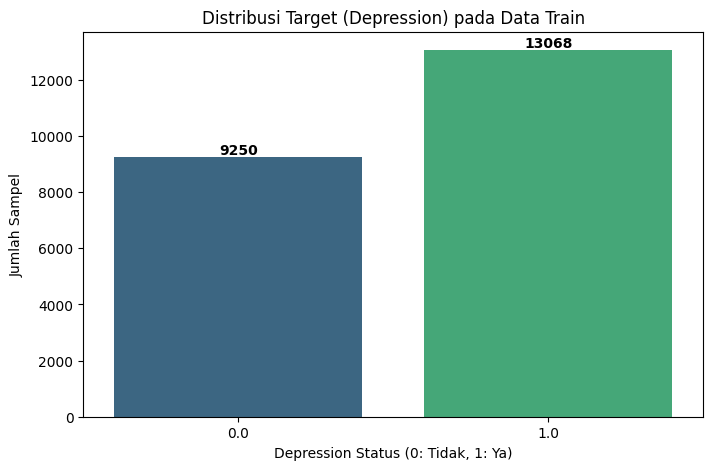

--- Persentase Distribusi Target di Data Train ---
Depression
1.0    58.553634
0.0    41.446366
Name: proportion, dtype: float64


In [27]:
# Visualisasi distribusi target pada data Train
plt.figure(figsize=(8, 5))
sns.countplot(x=y_train, hue=y_train, palette='viridis', legend=False)

plt.title('Distribusi Target (Depression) pada Data Train')
plt.xlabel('Depression Status (0: Tidak, 1: Ya)')
plt.ylabel('Jumlah Sampel')

# Menampilkan jumlah tiap kategori di atas bar
for i, count in enumerate(y_train.value_counts().sort_index()):
    plt.text(i, count + 100, str(count), ha='center', fontweight='bold')

plt.show()

# Menampilkan persentase
print("--- Persentase Distribusi Target di Data Train ---")
print(y_train.value_counts(normalize=True) * 100)

# Modeling Dengan Preprocessing

In [28]:
# 1. Inisialisasi Model Linear
linear_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "Ridge Classifier": RidgeClassifier(random_state=42)
}

# 2. Inisialisasi Model Non-Linear
non_linear_models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5)
}

# Gabungkan semua model
all_models = {**linear_models, **non_linear_models}

results = {}

print("--- Memulai Pelatihan dan Evaluasi Model ---\n")

for name, model in all_models.items():
    # Training
    model.fit(X_train_processed, y_train)

    # Prediction
    y_train_pred = model.predict(X_train_processed)
    y_test_pred = model.predict(X_test_processed)

    # Evaluation
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    results[name] = test_acc

    print(f"=== {name} ===")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print("\nClassification Report (Test Set):")
    print(classification_report(y_test, y_test_pred))
    print("-" * 30 + "\n")

# Ringkasan Akhir
print("--- Ringkasan Performa Model (Diurutkan berdasarkan Test Accuracy) ---")
sorted_results = dict(sorted(results.items(), key=lambda item: item[1], reverse=True))
for name, acc in sorted_results.items():
    print(f"{name}: {acc:.4f}")

--- Memulai Pelatihan dan Evaluasi Model ---

=== Logistic Regression ===
Train Accuracy: 0.8483
Test Accuracy: 0.8461

Classification Report (Test Set):
              precision    recall  f1-score   support

         0.0       0.83      0.79      0.81      2313
         1.0       0.86      0.89      0.87      3267

    accuracy                           0.85      5580
   macro avg       0.84      0.84      0.84      5580
weighted avg       0.85      0.85      0.85      5580

------------------------------

=== Support Vector Machine ===
Train Accuracy: 0.8588
Test Accuracy: 0.8425

Classification Report (Test Set):
              precision    recall  f1-score   support

         0.0       0.83      0.78      0.80      2313
         1.0       0.85      0.88      0.87      3267

    accuracy                           0.84      5580
   macro avg       0.84      0.83      0.84      5580
weighted avg       0.84      0.84      0.84      5580

------------------------------

=== Ridge Classif

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:49:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== XGBoost ===
Train Accuracy: 0.9084
Test Accuracy: 0.8421

Classification Report (Test Set):
              precision    recall  f1-score   support

         0.0       0.82      0.79      0.81      2313
         1.0       0.86      0.88      0.87      3267

    accuracy                           0.84      5580
   macro avg       0.84      0.83      0.84      5580
weighted avg       0.84      0.84      0.84      5580

------------------------------

=== K-Nearest Neighbors ===
Train Accuracy: 0.8693
Test Accuracy: 0.8115

Classification Report (Test Set):
              precision    recall  f1-score   support

         0.0       0.80      0.73      0.76      2313
         1.0       0.82      0.87      0.84      3267

    accuracy                           0.81      5580
   macro avg       0.81      0.80      0.80      5580
weighted avg       0.81      0.81      0.81      5580

------------------------------

--- Ringkasan Performa Model (Diurutkan berdasarkan Test Accuracy) ---
Logisti

# Hyperparameter Tuning

In [29]:
param_grid = [
    {
        'C': np.logspace(-4, 4, 10),
        'penalty': ['l2'],
        'solver': ['lbfgs', 'newton-cg', 'sag']
    },
    {
        'C': np.logspace(-4, 4, 10),
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear']
    },
    {
        'C': np.logspace(-4, 4, 10),
        'penalty': ['l1', 'l2', 'elasticnet'],
        'solver': ['saga'],
        'l1_ratio': [0.5]
    }
]

# 1. Inisialisasi Model
logreg = LogisticRegression(max_iter=5000, random_state=42)

# 2. Jalankan GridSearchCV
print("--- Memulai Hyperparameter Tuning Luas (GridSearchCV) ---")
grid_search = GridSearchCV(
    estimator=logreg,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1,
    scoring='accuracy'
)

# Fit pada data yang sudah di-scale
grid_search.fit(X_train_processed, y_train)

# 3. Hasil Terbaik
print("\n--- Hasil Tuning Terbaik ---")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")

# 4. Evaluasi pada Train dan Test Set
best_logreg = grid_search.best_estimator_

# Prediksi
y_pred_train = best_logreg.predict(X_train_processed)
y_pred_test = best_logreg.predict(X_test_processed)

print("\n--- Evaluasi Akhir (Extended Tuned Logistic Regression) ---")
print(f"Accuracy on Train Set: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Accuracy on Test Set: {accuracy_score(y_test, y_pred_test):.4f}")

print("\nClassification Report (Train Set):")
print(classification_report(y_train, y_pred_train))

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_test))

--- Memulai Hyperparameter Tuning Luas (GridSearchCV) ---
Fitting 5 folds for each of 80 candidates, totalling 400 fits

--- Hasil Tuning Terbaik ---
Best Parameters: {'C': np.float64(21.54434690031882), 'penalty': 'l2', 'solver': 'newton-cg'}
Best CV Accuracy: 0.8483

--- Evaluasi Akhir (Extended Tuned Logistic Regression) ---
Accuracy on Train Set: 0.8484
Accuracy on Test Set: 0.8461

Classification Report (Train Set):
              precision    recall  f1-score   support

         0.0       0.83      0.79      0.81      9250
         1.0       0.86      0.89      0.87     13068

    accuracy                           0.85     22318
   macro avg       0.85      0.84      0.84     22318
weighted avg       0.85      0.85      0.85     22318


Classification Report (Test Set):
              precision    recall  f1-score   support

         0.0       0.83      0.79      0.81      2313
         1.0       0.86      0.89      0.87      3267

    accuracy                           0.85      

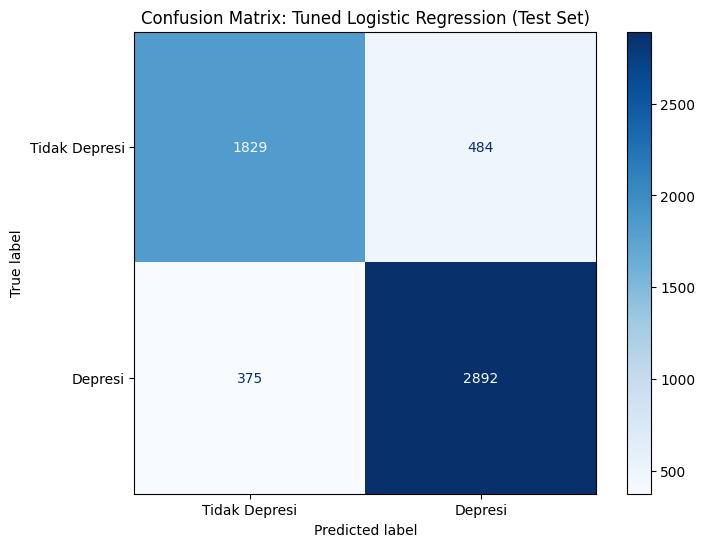

In [30]:
cm = confusion_matrix(y_test, y_pred_test)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Tidak Depresi', 'Depresi'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix: Tuned Logistic Regression (Test Set)')
plt.grid(False)
plt.show()

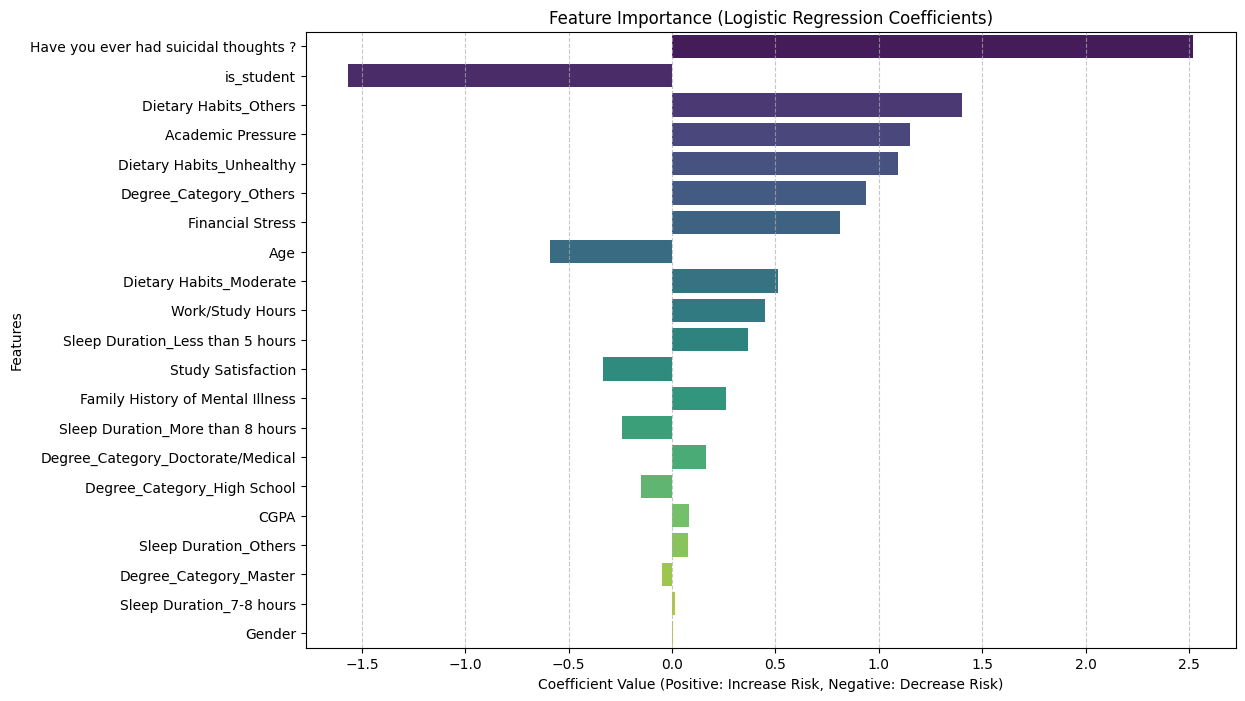

--- Top 10 Most Influential Features ---
                                  Feature  Importance
7   Have you ever had suicidal thoughts ?    2.521702
9                              is_student   -1.567544
11                  Dietary Habits_Others    1.402721
1                       Academic Pressure    1.151555
12               Dietary Habits_Unhealthy    1.094470
20                 Degree_Category_Others    0.936861
5                        Financial Stress    0.811496
0                                     Age   -0.589703
10                Dietary Habits_Moderate    0.510489
4                        Work/Study Hours    0.450839


In [31]:
# 1. Mendapatkan koefisien dari model terbaik
importances = best_logreg.coef_[0]
feature_names = semua_kolom

# 2. Membuat DataFrame untuk memudahkan plotting
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Mengurutkan berdasarkan nilai absolut
feature_importance_df['Abs_Importance'] = feature_importance_df['Importance'].abs()
feature_importance_df = feature_importance_df.sort_values(by='Abs_Importance', ascending=False)

# 3. Visualisasi dengan perbaikan hue untuk menghindari FutureWarning
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, hue='Feature', palette='viridis', legend=False)
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.xlabel('Coefficient Value (Positive: Increase Risk, Negative: Decrease Risk)')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Menampilkan 10 fitur teratas secara teks
print("--- Top 10 Most Influential Features ---")
print(feature_importance_df[['Feature', 'Importance']].head(10))

# Persiapan Deployment

In [32]:
# 1. Simpan Model Terbaik (Tuned Logistic Regression)
model_filename = 'best_depression_model.pkl'
with open(model_filename, 'wb') as f:
    pickle.dump(best_logreg, f)

# 2. Simpan Preprocessor (StandardScaler yang ada di ColumnTransformer)
preprocessor_filename = 'preprocessor.pkl'
with open(preprocessor_filename, 'wb') as f:
    pickle.dump(preprocessor, f)

# 3. Kumpulkan Metadata untuk Deployment
metadata = {
    'numerical_features': num_features, # ['Age', 'Academic Pressure', 'CGPA', 'Study Satisfaction', 'Work/Study Hours', 'Financial Stress']
    'categorical_manual_mappings': {
        'Family History of Mental Illness': family_history_mapping,
        'Have you ever had suicidal thoughts ?': suicidal_mapping,
        'Gender': gender_mapping
    },
    'categorical_special_processing': {
        'Profession': 'is_student logic (1 if Student else 0)',
        'Degree': 'grouped into Degree_Category (High School, Bachelor, Master, Doctorate/Medical, Others)',
        'Dietary Habits': 'cleaned (/// -> Others)'
    },
    'one_hot_encoded_cols_base': cols_to_ohe, # ['Dietary Habits', 'Sleep Duration', 'Degree_Category']
    'final_feature_order': semua_kolom, # Urutan kolom yang diharapkan oleh model
    'preprocessing_steps': [
        'Drop unused columns (id, City, Work Pressure, Job Satisfaction)',
        'Handle Outliers/Cleaning (/// to Others)',
        'Manual Binary Mapping (Gender, Suicidal, Family History)',
        'Feature Engineering (Degree Grouping, is_student)',
        'One-Hot Encoding (drop_first=True)',
        'Feature Scaling (StandardScaler on numerical features)'
    ]
}

# Simpan Metadata ke file JSON
metadata_filename = 'model_metadata.json'
with open(metadata_filename, 'w') as f:
    json.dump(metadata, f, indent=4)

print(f"--- Proses Ekspor Selesai ---")
print(f"1. Model disimpan ke: {model_filename}")
print(f"2. Preprocessor disimpan ke: {preprocessor_filename}")
print(f"3. Metadata deployment disimpan ke: {metadata_filename}")

--- Proses Ekspor Selesai ---
1. Model disimpan ke: best_depression_model.pkl
2. Preprocessor disimpan ke: preprocessor.pkl
3. Metadata deployment disimpan ke: model_metadata.json


In [33]:
import sklearn
print(f'Scikit-learn version: {sklearn.__version__}')
import sys
print(f'Python version: {sys.version}')

Scikit-learn version: 1.6.1
Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
